# Gold document in memory (memory-generation check)

Separate-store agent only (`agent_1`). Sample **10** questions that were not always right or always wrong on that agent, then re-run **that agent’s design-matrix rows** with one store change. **`document_only` is dropped**: gold evidence is not assigned to memory, so swapping the memory gold source is a no-op.

If gold evidence is assigned to **memory** (`memory_only` / `integrated`), the memory index holds the **gold article** (Chroma-chunked) instead of the generated gold **session**. Document exclusions, session strips, and background memory are unchanged.

Retrieval is scored like the generation audit: **one Bernoulli per assigned memory-gold session**, not per experimental row. Document-store gold on `integrated` rows is ignored.

Set `RUN_INFERENCE = True` to run Groq (rebuilds three persona stores once for agent_1). 

In [1]:
from pathlib import Path
import sys

REPO = Path.cwd()
if not (REPO / "analysis" / "qualitative.py").exists():
    REPO = Path.cwd().parent.parent
sys.path.insert(0, str(REPO))

import pandas as pd
from IPython.display import Markdown, display

from analysis.qualitative import (
    SAMPLE_SEED,
    SEPARATE_STORE_AGENT,
    explode_memory_gold_identity_hits,
    label_runs,
    load_features,
    load_labeled_runs,
    load_merged_design,
    run_design_subset,
    sample_variable_questions,
)
from experiment.paths import DEFAULT_EXPERIMENT_QUESTIONS_PICKLE

AGENT = SEPARATE_STORE_AGENT  # agent_1, chroma separate store

features = load_features()
labeled = load_labeled_runs()
block_ids = sample_variable_questions(features, agent=AGENT, n=10, seed=SAMPLE_SEED)

design = load_merged_design()
memory_dists = design["dist"].ne("document_only")
design_sub = design[
    design["Block1"].isin(block_ids) & (design["agent"] == AGENT) & memory_dists
].copy()
orig = labeled[
    labeled["block_id"].isin(block_ids)
    & (labeled["agent"] == AGENT)
    & labeled["dist"].ne("document_only")
].copy()

display(Markdown(
    f"Questions: `{block_ids}`  \n"
    f"Design rows for **{AGENT}**: **{len(design_sub)}** "
    f"(orig labeled rows: {len(orig)})"
))
display(design_sub.groupby(["dist", "persona"]).size().unstack(fill_value=0))
display(orig.groupby("block_id")["correct"].agg(["mean", "sum", "count"]))

Questions: `[162, 183, 5, 134, 15, 184, 34, 25, 195, 74]`  
Design rows for **agent_1**: **27** (orig labeled rows: 27)

persona,persona_1,persona_2,persona_3
dist,,,
integrated,4,4,4
memory_only,5,5,5


,mean,sum,count
block_id,,,
5,0.333333,1,3
15,0.666667,2,3
25,0.666667,2,3
34,0.666667,2,3
74,0.666667,2,3
134,0.666667,2,3
162,0.666667,2,3
184,0.666667,2,3
195,0.666667,2,3


In [2]:
RUN_INFERENCE = False # set True to call Groq

out_path = REPO / "data" / "experiment_runs" / "gold_doc_memory" / f"{AGENT}.jsonl"
questions = pd.read_pickle(DEFAULT_EXPERIMENT_QUESTIONS_PICKLE)


if out_path.exists():
    new = pd.read_json(out_path, lines=True)
    print(f"Loaded existing {out_path} ({len(new)} rows)")
elif RUN_INFERENCE:
    recs = run_design_subset(
        AGENT,
        design_sub,
        out_path,
        memory_gold_source="gold_document",
    )
    new = pd.DataFrame(recs)
    out_path.write_text(new.to_json(orient="records", lines=True), encoding="utf-8")
    print(f"Wrote {out_path} ({len(new)} rows)")

Loaded existing /home/funkytunk/Desktop/Repositories/memdoc/data/experiment_runs/gold_doc_memory/agent_1.jsonl (30 rows)


In [5]:



if not new.empty:
    new_l = explode_memory_gold_identity_hits(
        label_runs(new, questions), match="gold_document", col="hit_gold_document",
    )
    orig_s = explode_memory_gold_identity_hits(
        orig.copy(), match="session", col="hit_gold_session",
    )

    keys = ["block_id", "persona", "dist", "agent", "session_id"]
    cmp = orig_s[keys + ["correct", "hit_gold_session", "prediction"]].merge(
        new_l[keys + ["correct", "hit_gold_document", "prediction"]],
        on=keys,
        suffixes=("_session", "_gold_doc"),
    )
    cmp = cmp.loc[cmp["dist"].isin(["memory_only", "integrated"])].copy()
    cmp["dist"] = pd.Categorical(cmp["dist"], categories=["memory_only", "integrated"], ordered=True)
    cmp["delta_em"] = cmp["correct_gold_doc"] - cmp["correct_session"]
    cmp["delta_hit"] = cmp["hit_gold_document"].astype(int) - cmp["hit_gold_session"].astype(int)
    run_keys = ["block_id", "persona", "dist", "agent"]
    runs = cmp.drop_duplicates(run_keys)
    display(Markdown(
        "### Per-evidence comparison (audit unit: one row per assigned memory-gold session)"
    ))
    display(cmp.sort_values(["block_id", "persona", "dist", "session_id"]))
    display(Markdown("### Identity hit rate (per gold session)"))
    display(cmp.groupby("dist", observed=True)[["hit_gold_session", "hit_gold_document", "delta_hit"]].mean())
    display(Markdown("### Exact match (per experimental run, not exploded)"))
    display(runs.groupby("dist", observed=True)[["correct_session", "correct_gold_doc", "delta_em"]].mean())
    display(Markdown("### Hit rate by question"))
    display(cmp.groupby("block_id")[["hit_gold_session", "hit_gold_document", "delta_hit"]].mean())

### Per-evidence comparison (audit unit: one row per assigned memory-gold session)

,block_id,persona,dist,agent,session_id,correct_session,hit_gold_session,prediction_session,correct_gold_doc,hit_gold_document,prediction_gold_doc,delta_em,delta_hit
0,5,persona_1,integrated,agent_1,q-3a5cda5703cde2d5__ev-988cc659d2cd79133fe5d77...,0,False,Google,0,True,[INFERENCE_FAILED],0,1
1,5,persona_1,integrated,agent_1,q-3a5cda5703cde2d5__ev-a9f685baf26852169c0b7dd...,0,False,Google,0,False,[INFERENCE_FAILED],0,0
18,5,persona_2,integrated,agent_1,q-3a5cda5703cde2d5__ev-988cc659d2cd79133fe5d77...,1,False,Apple,0,True,[INFERENCE_FAILED],-1,1
19,5,persona_2,integrated,agent_1,q-3a5cda5703cde2d5__ev-a9f685baf26852169c0b7dd...,1,False,Apple,0,False,[INFERENCE_FAILED],-1,0
36,5,persona_3,integrated,agent_1,q-3a5cda5703cde2d5__ev-988cc659d2cd79133fe5d77...,0,False,Google,0,True,[INFERENCE_FAILED],0,1
37,5,persona_3,integrated,agent_1,q-3a5cda5703cde2d5__ev-a9f685baf26852169c0b7dd...,0,False,Google,0,True,[INFERENCE_FAILED],0,1
2,15,persona_1,integrated,agent_1,q-af03fbbcefb4818a__ev-1f94b16dfceeb21ff7aa7b0...,0,True,Insufficient Information,0,True,[INFERENCE_FAILED],0,0
20,15,persona_2,integrated,agent_1,q-af03fbbcefb4818a__ev-1f94b16dfceeb21ff7aa7b0...,1,True,No,0,True,[INFERENCE_FAILED],-1,0
38,15,persona_3,integrated,agent_1,q-af03fbbcefb4818a__ev-1f94b16dfceeb21ff7aa7b0...,1,True,No,0,True,[INFERENCE_FAILED],-1,0
3,25,persona_1,memory_only,agent_1,q-ab1eac59f3f9ac59__ev-1fc09c817ccda25ce0827e2...,1,False,Yes,0,True,[INFERENCE_FAILED],-1,1


### Identity hit rate (per gold session)

,hit_gold_session,hit_gold_document,delta_hit
dist,,,
memory_only,0.589744,0.461538,-0.128205
integrated,0.400000,0.866667,0.466667


### Exact match (per experimental run, not exploded)

,correct_session,correct_gold_doc,delta_em
dist,,,
memory_only,0.666667,0.0,-0.666667
integrated,0.583333,0.0,-0.583333


### Hit rate by question

,hit_gold_session,hit_gold_document,delta_hit
block_id,,,
5,0.000000,0.666667,0.666667
15,1.000000,1.000000,0.000000
25,0.333333,0.444444,0.111111
34,0.333333,1.000000,0.666667
74,0.666667,1.000000,0.333333
134,1.000000,0.833333,-0.166667
162,0.777778,0.666667,-0.111111
184,0.833333,0.000000,-0.833333
195,0.222222,0.333333,0.111111


### Retrieval impact (identity hit per assigned memory-gold session)

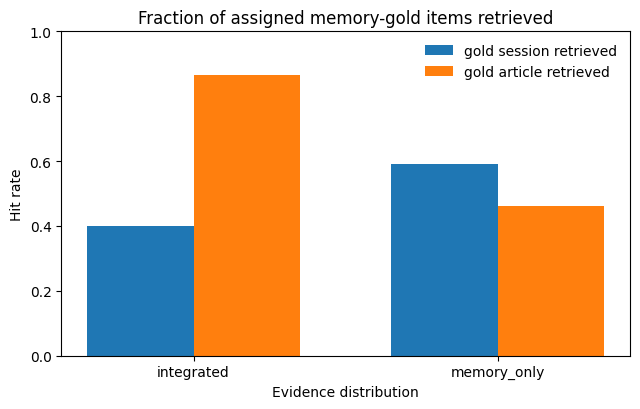

In [7]:
import matplotlib.pyplot as plt

display(Markdown("### Retrieval impact (identity hit per assigned memory-gold session)"))

means = (
    cmp.groupby("dist", observed=True)[["hit_gold_session", "hit_gold_document"]]
    .mean()
    .reindex(["integrated", "memory_only"])
)
x = range(len(means))
w = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar([i - w / 2 for i in x], means["hit_gold_session"], width=w, label="gold session retrieved")
ax.bar(
    [i + w / 2 for i in x],
    means["hit_gold_document"],
    width=w,
    label="gold article retrieved",
)
ax.set_xticks(list(x), means.index)
ax.set_ylim(0, 1)
ax.set_xlabel("Evidence distribution")
ax.set_ylabel("Hit rate")
ax.set_title("Fraction of assigned memory-gold items retrieved")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()